In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os
import torch
import numpy as np
sys.path.append(os.path.abspath('../scripts'))
from supporting.load_data import load_data, build_data_loaders, x_scale, y_scale, y_unscale
from sklearn import metrics
from torch import nn, optim
import torch.nn.functional as F

In [13]:
def get_device():
    ''' function to get the device the NN is running on, CPU or GPU
    '''
    if torch.cuda.is_available():
        device = torch.device("cuda:0")
    else: 
        device = torch.device("cpu")
        
    return device

In [14]:
config = {
    "model_type": "skip-mini",
    "input_shape": 4,
    "amplitude_shape": 36,
    "data_dir": "/scratch/akula.ha/dataset",
    "seed": 1,
    "var_y": [
        "y5",
        "y6"
    ],
    "use_MC_sample": True,
    "val_MC": False,
    "train-sample-size": 10000000,
    "validate-sample-size": 500000,
    "test-sample-size": 500000,
    "activation": "leaky_relu",
    "width": 30,
    "depth": 12,
    "skip_block_layers": 5,
    "lr_decay_type": "plateau",
    "initial_lr": 0.001,
    "lr_patience": 20,
    "lr_factor": 0.8,
    "lr_delta": 1e-05,
    "batch_size": 1024,
    "steps_per_epoch": 2400,
    "early_stopping_start_epoch": 200,
    "patience": 250,
    "loss": "huber",
    "base_directory": "../models/",
    "epochs": 2000,
    "model-uuid": "y5y6m1",
    "train-samples-used": 6,
    "validate-samples-used": 6,
    "test-samples-used": 6,
    "n_targets": 2,
    "load_checkpoint_path": "/projects/talisman/akulaha/qqzz4l-NN/models/skip-mini_y5y6m1_30_12_5"
}

In [15]:
torch.set_default_dtype(torch.float64)

In [16]:
class MyDataset(torch.utils.data.Dataset):
    '''Class to convert dataframe to torch tensor'''
    def __init__(self, x, y, config):
        x = x.copy(deep=True)
        y = y.copy(deep=True)

        # Vectorized scaling (if applicable)
        x['x1'] = x_scale(x['x1'])  # Or use apply if x_scale isn't vectorized

        # Number of targets
        config['n_targets'] = y.shape[1]

        for column in y.columns:
            y[column] = y[column].apply(y_scale)

        device = get_device()
        self.x = torch.tensor(x.values, dtype=torch.float64).to(device)
        self.y = torch.tensor(y.values, dtype=torch.float64).reshape(-1, config['n_targets']).to(device)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

df, spark = load_data(config)

x_cols = ['x1', 'x2', 'x3', 'x4']
y_cols = config["var_y"]
x_train = df["train"][x_cols]
y_train = df["train"][y_cols]
x_val = df["validate"][x_cols]
y_val = df["validate"][y_cols]
x_test = df["test"][x_cols]
y_test = df["test"][y_cols]

train_dataset = MyDataset(x_train, y_train, config)
val_dataset   = MyDataset(x_val, y_val, config)
test_dataset  = MyDataset(x_test, y_test, config)

# load the data into torch tensor batches
batch_size = config["batch_size"]
numworkers = 4 if get_device().type == 'cpu' else 0

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=numworkers, drop_last=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=True, num_workers=numworkers, drop_last=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=numworkers, drop_last=True)


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/18 01:11:52 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


[]
['y5', 'y6']


In [6]:
# model_path = "/projects/talisman/akulaha/qqzz4l-NN/models/skip-mini_9fdebfab_30_12_5/9fdebfab.best_weights.pt"

In [20]:
def test_model(model, test_data, config):
    ''' function for testing the model
        arguments:
            model: the pytorch model to nbe trained
            test_data: the test data loader
            config: the configurations file
        returns:
            the absolute error
            the R2 score
    '''
    
    for i, data in enumerate(test_data):
        
        # forward prop
        x, y = data
        y_p = model(x)
        
        # store data
        if i == 0:
            x_test = x.cpu().detach().numpy()
            y_test = y.cpu().detach().numpy()
            y_pred = y_p.cpu().detach().numpy()
        else: 
            x_test = np.vstack((x_test, x.cpu().detach().numpy()))
            y_test = np.vstack((y_test, y.cpu().detach().numpy()))
            y_pred = np.vstack((y_pred, y_p.cpu().detach().numpy()))
        
    
    # accuracy
    y_test = np.array(y_test).reshape(-1, config['n_targets'])
    y_pred = np.array(y_pred).reshape(-1, config['n_targets'])
    abs_score = (1 - np.mean(np.abs((y_pred - y_test)/y_test)))*100
    r2_score = metrics.r2_score(y_test, y_pred)*100
    
    # save test results
    df_pred = pd.DataFrame(x_test, columns=['x'+str(i+1) for i in range(config['input_shape'])])
    
    # unscale the target
    scaled_cname = [s + '_scaled' for s in config['var_y']]
    df_pred = pd.concat([df_pred, pd.DataFrame(y_test, columns=scaled_cname)], axis=1)
    for col in df_pred.columns[4:]:
        df_pred[col[:-7]] = df_pred[col].apply(lambda y: y_unscale(y))
    # y_test_real = pd.DataFrame(np.vectorize(y_unscale)(y_test), columns=config['var_y']) # 
    # df_pred = pd.concat([df_pred, y_test_real], axis=1)
    y_test_real = df_pred.iloc[:,-config['n_targets']:].to_numpy()
    
    # stuff in the scaled predictions
    pred_cname = [s + '_scaled_pred' for s in config['var_y']]
    df_pred = pd.concat([df_pred, pd.DataFrame(y_pred, columns=pred_cname)], axis=1)
    
    # stuff in the unscaled predictions
    pred_cname = [s + '_pred' for s in config['var_y']]
    for col in df_pred.columns[-config['n_targets']:]:
        df_pred[col[:-12]+'_pred'] = df_pred[col].apply(lambda y: y_unscale(y))
    # y_pred_real = pd.DataFrame(np.vectorize(y_unscale)(y_pred), columns=pred_cname) # .apply(lambda y: y_unscale(y))
    # df_pred = pd.concat([df_pred, y_pred_real], axis=1)
    y_pred_real = df_pred.iloc[:,-config['n_targets']:].to_numpy()
    
    # calculate the deltas for the scaled and unscaled targets
    scaled_delta_cname = ['scaled_delta_' + s for s in config['var_y']]
    df_pred = pd.concat([df_pred, pd.DataFrame((y_pred - y_test)/y_test*100, columns=scaled_delta_cname)], axis=1)
    delta_cname = ['delta_' + s for s in config['var_y']]
    df_pred = pd.concat([df_pred, pd.DataFrame((y_pred_real - y_test_real)/y_test_real*100, columns=delta_cname)], axis=1)
    
    #same the whole dataframe
    #df_pred.to_csv(config['directory']+'/test-results-'+config['model-uuid']+'-'+f'{abs_score:.6f}-{r2_score:.6f}.csv')
    
    # # plot all the scaled and real deltas
    # for c in scaled_delta_cname:
    #     make_error_plot(config, df_pred, col=c)
    # for c in delta_cname:
    #     make_error_plot(config, df_pred, col=c)
        
    test_metrics = {}
    test_metrics['r2'] = {}
    test_metrics['abs_score'] = {}
    num_vars = len(config['var_y'])
    base_length = config['input_shape'] + num_vars
    for i in range(base_length, base_length + num_vars):
        test = df_pred.iloc[:,i].values
        pred = df_pred.iloc[:,i + 2 * num_vars].values
        test_metrics['r2'][config['var_y'][i - base_length]] = metrics.r2_score(test, pred)*100
        test_metrics['abs_score'][config['var_y'][i - base_length]] = 100 - np.abs(df_pred.iloc[:,i + 4 * num_vars]).mean()
    
    test_metrics['r2']['model'] = r2_score
    test_metrics['abs_score']['model'] = abs_score
    
    return test_metrics, df_pred


In [21]:
def get_activation(activation_str):
    if activation_str == 'leaky_relu':
        return nn.LeakyReLU()
    elif activation_str == 'relu':
        return nn.ReLU()
    if activation_str == 'softplus':
        return nn.Softplus()
    if activation_str == 'swish':
        return nn.SiLU()
    if activation_str == 'sigmoid':
        return nn.Sigmoid()
    if activation_str == 'tanh':
        return nn.Tanh()
    if activation_str == 'prelu':
        return nn.PReLU()
    if activation_str == 'elu':
        return nn.ELU()

# Residual module (equivalent to 'module' in Keras)
class ResidualBlock(nn.Module):
    def __init__(self, in_dim, width, n_skip_layers, activation='swish'):
        super().__init__()
        layers = []
        orig_in_dim = in_dim
        for _ in range(n_skip_layers - 1):
            layers.append(nn.Linear(in_dim, width))
            layers.append(get_activation(activation))
            in_dim = width
        layers.append(nn.Linear(width, orig_in_dim))  # projection back to input dim
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return x + self.net(x)

# Full model (equivalent to 'model' in Keras)
class SkipModel(nn.Module):
    def __init__(self, input_dim, width, depth, n_skip_layers, output_dim, activation='swish'):
        super().__init__()
        self.input_layer = nn.Sequential(
            nn.Linear(input_dim, width),
            get_activation(activation)
        )
        self.res_blocks = nn.Sequential(*[
            ResidualBlock(in_dim=width, width=width, n_skip_layers=n_skip_layers, activation=activation) for _ in range(depth)
        ])
        self.output_layer = nn.Linear(width, output_dim)

    def forward(self, x):
        x = self.input_layer(x)
        x = self.res_blocks(x)
        return self.output_layer(x)


In [22]:
width = config['width']
depth = config['depth']
n_skip_layers = config['skip_block_layers']
activation = config['activation']

model = SkipModel(config["input_shape"], width, depth, n_skip_layers, len(y_cols), activation)
model.to(device=get_device())

SkipModel(
  (input_layer): Sequential(
    (0): Linear(in_features=4, out_features=30, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
  )
  (res_blocks): Sequential(
    (0): ResidualBlock(
      (net): Sequential(
        (0): Linear(in_features=30, out_features=30, bias=True)
        (1): LeakyReLU(negative_slope=0.01)
        (2): Linear(in_features=30, out_features=30, bias=True)
        (3): LeakyReLU(negative_slope=0.01)
        (4): Linear(in_features=30, out_features=30, bias=True)
        (5): LeakyReLU(negative_slope=0.01)
        (6): Linear(in_features=30, out_features=30, bias=True)
        (7): LeakyReLU(negative_slope=0.01)
        (8): Linear(in_features=30, out_features=30, bias=True)
      )
    )
    (1): ResidualBlock(
      (net): Sequential(
        (0): Linear(in_features=30, out_features=30, bias=True)
        (1): LeakyReLU(negative_slope=0.01)
        (2): Linear(in_features=30, out_features=30, bias=True)
        (3): LeakyReLU(negative_slope=0.01)
     

In [23]:
best_weights_path = model_path
model.load_state_dict(torch.load(best_weights_path, map_location=torch.device('cuda' if torch.cuda.is_available() else 'cpu')))

NameError: name 'model_path' is not defined

In [16]:
test_metrics, df_pred = test_model(model, test_loader, config)

In [23]:
test_metrics

{'r2': {'y17': 99.964480082359,
  'y18': 99.9951408525495,
  'model': 99.9974149364824},
 'abs_score': {'y17': 98.34189944785079,
  'y18': 99.49325872457503,
  'model': 99.2961952827994}}

In [25]:
test_metrics

{'r2': {'y17': 99.964480082359,
  'y18': 99.9951408525495,
  'model': 99.9974149364824},
 'abs_score': {'y17': 98.34189944785079,
  'y18': 99.49325872457503,
  'model': 99.2961952827994}}

# Eval code

# Error plots 

## h2 real and imaginary

In [3]:
import os, json
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_percentage_error, r2_score

def _percent_delta(y_true, y_pred, eps=1e-6):
    """(y_pred - y_true)/y_true * 100 without zero-guard."""
    return (y_pred - y_true) / (y_true + eps) * 100.0

def _plot_error_histograms(delta_matrix, labels, cutoff=5, title="Error Histogram Overlay"):
    """Overlay histogram for each target column in delta_matrix."""
    plt.figure(figsize=(8, 5))
    for j, name in enumerate(labels):
        col = delta_matrix[:, j]
        m = np.isfinite(col)
        if cutoff is not None:
            m &= (np.abs(col) < cutoff)
        data = col[m]
        if data.size == 0:
            continue
        plt.hist(data, bins=100, histtype='step', label=name, density=True)
    plt.grid(True, linestyle='dotted', alpha=0.5)
    plt.xlabel(r'$\delta$ (%)')
    plt.ylabel('pdf')
    plt.title(title)
    plt.legend()
    plt.show()

In [4]:
def evaluate_model(model, dataloader, device, config):
    """
    Evaluate a trained model and display metrics and histograms.
    Requires a globally available y_unscale(y) -> float function.
    """
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for xb, yb in dataloader:
            xb = xb.to(device)
            pred = model(xb).cpu()
            all_preds.append(pred)
            all_targets.append(yb.cpu())

    y_true = torch.cat(all_targets, dim=0).numpy()
    y_pred = torch.cat(all_preds, dim=0).numpy()

    y_names = config["var_y"]
    assert y_true.ndim == 2 and y_true.shape[1] == len(y_names)

    # --- Scaled metrics ---
    scaled = {}
    overall_mape = mean_absolute_percentage_error(y_true, y_pred)
    overall_r2   = r2_score(y_true, y_pred)
    overall_abs  = (1 - overall_mape) * 100 if np.isfinite(overall_mape) else np.nan
    scaled["overall"] = {"MAPE": overall_mape, "R2": overall_r2, "abs_score": overall_abs}
    scaled["per_target"] = {}
    for j, name in enumerate(y_names):
        mape_j = mean_absolute_percentage_error(y_true[:, j], y_pred[:, j])
        r2_j   = r2_score(y_true[:, j], y_pred[:, j])
        abs_j  = (1 - mape_j) * 100 if np.isfinite(mape_j) else np.nan
        scaled["per_target"][name] = {"MAPE": mape_j, "R2": r2_j, "abs_score": abs_j}

    # --- Unscaled metrics ---
    y_unscale_vec = np.vectorize(y_unscale)
    y_true_un = y_unscale_vec(y_true)
    y_pred_un = y_unscale_vec(y_pred)

    unscaled = {}
    overall_mape_un = mean_absolute_percentage_error(y_true_un, y_pred_un)
    overall_r2_un   = r2_score(y_true_un, y_pred_un)
    overall_abs_un  = (1 - overall_mape_un) * 100 if np.isfinite(overall_mape_un) else np.nan
    unscaled["overall"] = {"MAPE": overall_mape_un, "R2": overall_r2_un, "abs_score": overall_abs_un}
    unscaled["per_target"] = {}
    for j, name in enumerate(y_names):
        mape_j_un = mean_absolute_percentage_error(y_true_un[:, j], y_pred_un[:, j])
        r2_j_un   = r2_score(y_true_un[:, j], y_pred_un[:, j])
        abs_j_un  = (1 - mape_j_un) * 100 if np.isfinite(mape_j_un) else np.nan
        unscaled["per_target"][name] = {"MAPE": mape_j_un, "R2": r2_j_un, "abs_score": abs_j_un}

    # --- Print results ---
    print("\n=== Evaluation (SCALED) ===")
    print(f"Overall MAPE: {scaled['overall']['MAPE']:.6f}")
    print(f"Overall R2  : {scaled['overall']['R2']:.6f}")
    print(f"Overall Abs : {scaled['overall']['abs_score']:.6f}")
    for n, v in scaled["per_target"].items():
        print(f"{n}: MAPE={v['MAPE']:.6f}, R2={v['R2']:.6f}, abs={v['abs_score']:.6f}")

    print("\n=== Evaluation (UNSCALED) ===")
    print(f"Overall MAPE: {unscaled['overall']['MAPE']:.6f}")
    print(f"Overall R2  : {unscaled['overall']['R2']:.6f}")
    print(f"Overall Abs : {unscaled['overall']['abs_score']:.6f}")
    for n, v in unscaled["per_target"].items():
        print(f"{n}: MAPE={v['MAPE']:.6f}, R2={v['R2']:.6f}, abs={v['abs_score']:.6f}")

    # --- Histograms ---
    scaled_delta   = _percent_delta(y_true, y_pred)
    unscaled_delta = _percent_delta(y_true_un, y_pred_un)

    _plot_error_histograms(unscaled_delta, y_names, cutoff=5, title="Unscaled Errors")
    _plot_error_histograms(scaled_delta, y_names, cutoff=5, title="Scaled Errors")

    return scaled, unscaled

### Tweaking the MAPE denominator regularization

In [5]:
def safe_mape(y_true, y_pred, eps=1e-6):
    """
    Mean Absolute Percentage Error with denominator guard.
    Adds eps to denominator to avoid blow-up near zero.
    """
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    return np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + eps)))


def _percent_delta(y_true, y_pred, eps=1e-6):
    """
    Percentage delta with epsilon guard:
    (y_pred - y_true) / (y_true + eps) * 100
    """
    return (y_pred - y_true) / (y_true + eps) * 100.0


def _plot_error_histograms(delta_matrix, labels, cutoff=5, title="Error Histogram Overlay"):
    """Overlay histogram for each target column in delta_matrix."""
    plt.figure(figsize=(8, 5))
    for j, name in enumerate(labels):
        col = delta_matrix[:, j]
        m = np.isfinite(col)
        if cutoff is not None:
            m &= (np.abs(col) < cutoff)
        data = col[m]
        if data.size == 0:
            continue
        plt.hist(data, bins=100, histtype='step', label=name, density=True)
    plt.grid(True, linestyle='dotted', alpha=0.5)
    plt.xlabel(r'$\delta$ (%)')
    plt.ylabel('pdf')
    plt.title(title)
    plt.legend()
    plt.show()


In [6]:
def evaluate_model(model, dataloader, device, config, eps=1e-6):
    """
    Evaluate a trained model and display metrics and histograms.
    eps: small constant to stabilize denominators in MAPE and deltas.
    """
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for xb, yb in dataloader:
            xb = xb.to(device)
            pred = model(xb).cpu()
            all_preds.append(pred)
            all_targets.append(yb.cpu())

    y_true = torch.cat(all_targets, dim=0).numpy()
    y_pred = torch.cat(all_preds, dim=0).numpy()

    y_names = config["var_y"]
    assert y_true.ndim == 2 and y_true.shape[1] == len(y_names)

    # --- Scaled metrics ---
    scaled = {}
    overall_mape = safe_mape(y_true, y_pred, eps=eps)
    overall_r2   = r2_score(y_true, y_pred)
    overall_abs  = (1 - overall_mape) * 100 if np.isfinite(overall_mape) else np.nan
    scaled["overall"] = {"MAPE": overall_mape, "R2": overall_r2, "abs_score": overall_abs}
    scaled["per_target"] = {}
    for j, name in enumerate(y_names):
        mape_j = safe_mape(y_true[:, j], y_pred[:, j], eps=eps)
        r2_j   = r2_score(y_true[:, j], y_pred[:, j])
        abs_j  = (1 - mape_j) * 100 if np.isfinite(mape_j) else np.nan
        scaled["per_target"][name] = {"MAPE": mape_j, "R2": r2_j, "abs_score": abs_j}

    # --- Unscaled metrics ---
    y_unscale_vec = np.vectorize(y_unscale)
    y_true_un = y_unscale_vec(y_true)
    y_pred_un = y_unscale_vec(y_pred)

    unscaled = {}
    overall_mape_un = safe_mape(y_true_un, y_pred_un, eps=eps)
    overall_r2_un   = r2_score(y_true_un, y_pred_un)
    overall_abs_un  = (1 - overall_mape_un) * 100 if np.isfinite(overall_mape_un) else np.nan
    unscaled["overall"] = {"MAPE": overall_mape_un, "R2": overall_r2_un, "abs_score": overall_abs_un}
    unscaled["per_target"] = {}
    for j, name in enumerate(y_names):
        mape_j_un = safe_mape(y_true_un[:, j], y_pred_un[:, j], eps=eps)
        r2_j_un   = r2_score(y_true_un[:, j], y_pred_un[:, j])
        abs_j_un  = (1 - mape_j_un) * 100 if np.isfinite(mape_j_un) else np.nan
        unscaled["per_target"][name] = {"MAPE": mape_j_un, "R2": r2_j_un, "abs_score": abs_j_un}

    # --- Print results ---
    print("\n=== Evaluation (SCALED) ===")
    print(f"Overall MAPE: {scaled['overall']['MAPE']:.6f}")
    print(f"Overall R2  : {scaled['overall']['R2']:.6f}")
    print(f"Overall Abs : {scaled['overall']['abs_score']:.6f}")
    for n, v in scaled["per_target"].items():
        print(f"{n}: MAPE={v['MAPE']:.6f}, R2={v['R2']:.6f}, abs={v['abs_score']:.6f}")

    print("\n=== Evaluation (UNSCALED) ===")
    print(f"Overall MAPE: {unscaled['overall']['MAPE']:.6f}")
    print(f"Overall R2  : {unscaled['overall']['R2']:.6f}")
    print(f"Overall Abs : {unscaled['overall']['abs_score']:.6f}")
    for n, v in unscaled["per_target"].items():
        print(f"{n}: MAPE={v['MAPE']:.6f}, R2={v['R2']:.6f}, abs={v['abs_score']:.6f}")

    # --- Histograms ---
    scaled_delta   = _percent_delta(y_true, y_pred, eps=eps)
    unscaled_delta = _percent_delta(y_true_un, y_pred_un, eps=eps)

    _plot_error_histograms(unscaled_delta, y_names, cutoff=5, title="Unscaled Errors")
    _plot_error_histograms(scaled_delta, y_names, cutoff=5, title="Scaled Errors")

    return scaled, unscaled



=== Evaluation (SCALED) ===
Overall MAPE: 0.172711
Overall R2  : 0.999869
Overall Abs : 82.728947
y17: MAPE=0.011323, R2=0.999946, abs=98.867728
y18: MAPE=0.334098, R2=0.999791, abs=66.590166

=== Evaluation (UNSCALED) ===
Overall MAPE: 0.175302
Overall R2  : 0.984146
Overall Abs : 82.469783
y17: MAPE=0.014238, R2=0.971229, abs=98.576198
y18: MAPE=0.336366, R2=0.997064, abs=66.363367


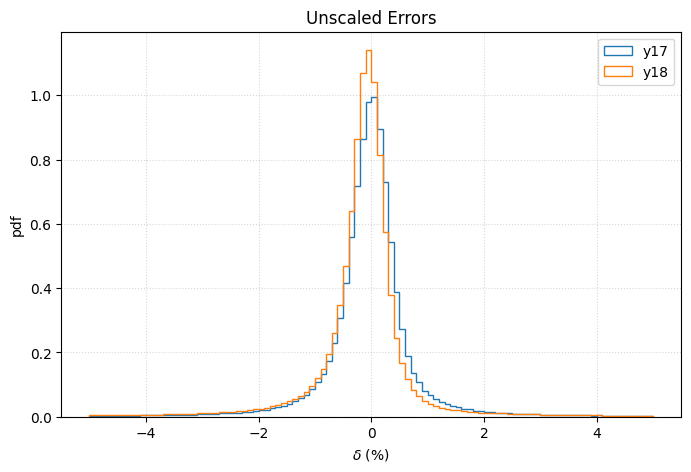

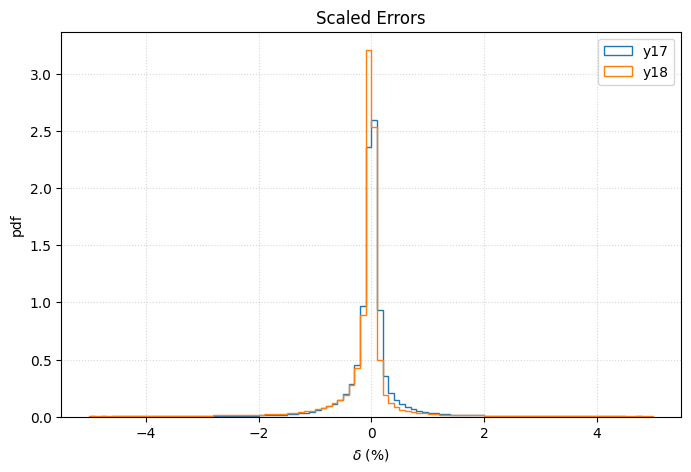

In [91]:
scaled_metrics, unscaled_metrics = evaluate_model(
    model, test_loader, get_device(), config, eps=0
)


=== Evaluation (SCALED) ===
Overall MAPE: 0.007038
Overall R2  : 0.999974
Overall Abs : 99.296231
y17: MAPE=0.011984, R2=0.999968, abs=98.801637
y18: MAPE=0.002092, R2=0.999980, abs=99.790826

=== Evaluation (UNSCALED) ===
Overall MAPE: 0.010824
Overall R2  : 0.999798
Overall Abs : 98.917615
y17: MAPE=0.016580, R2=0.999645, abs=98.341967
y18: MAPE=0.005067, R2=0.999951, abs=99.493264


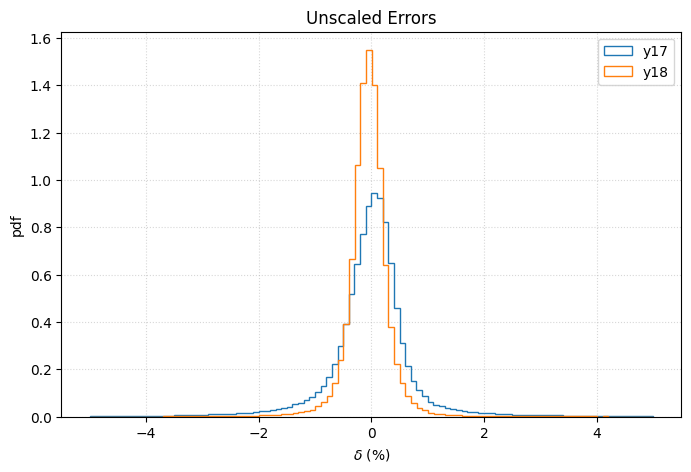

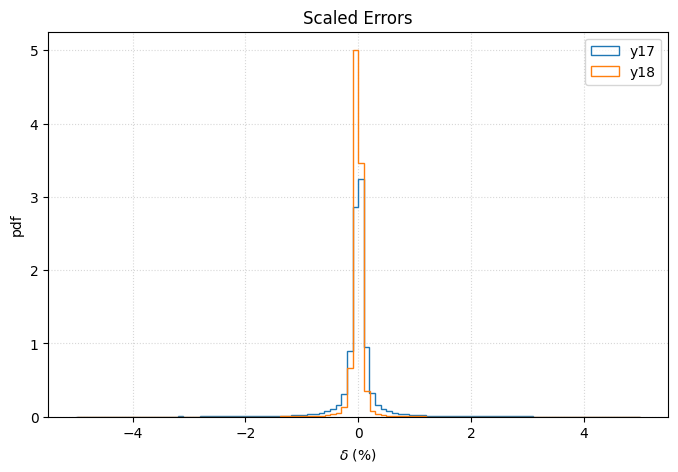

In [72]:
scaled_metrics, unscaled_metrics = evaluate_model(
    model, test_loader, get_device(), config, eps=1e-8
)


=== Evaluation (SCALED) ===
Overall MAPE: 0.007003
Overall R2  : 0.999974
Overall Abs : 99.299681
y17: MAPE=0.011920, R2=0.999968, abs=98.808027
y18: MAPE=0.002087, R2=0.999980, abs=99.791334

=== Evaluation (UNSCALED) ===
Overall MAPE: 0.010789
Overall R2  : 0.999798
Overall Abs : 98.921085
y17: MAPE=0.016516, R2=0.999645, abs=98.348394
y18: MAPE=0.005062, R2=0.999951, abs=99.493776


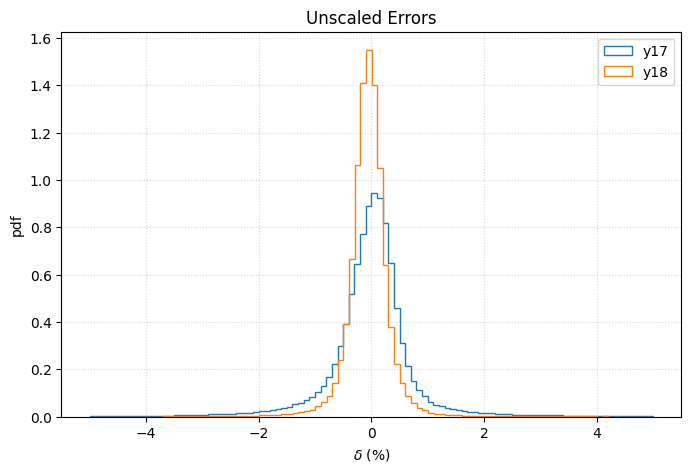

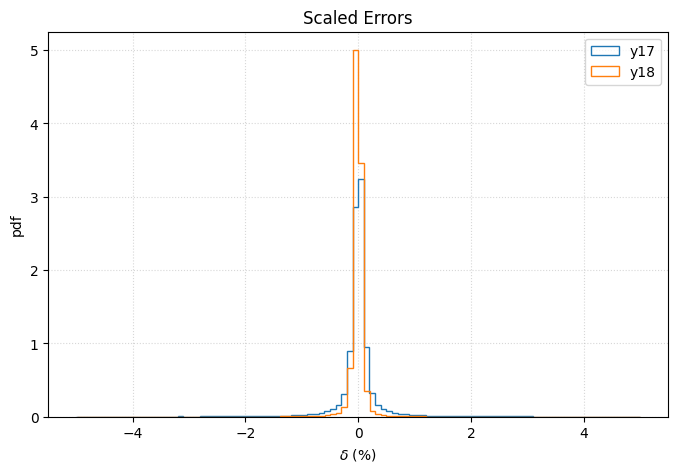

In [76]:
scaled_metrics, unscaled_metrics = evaluate_model(
    model, test_loader, get_device(), config, eps=1e-6
)


=== Evaluation (SCALED) ===
Overall MAPE: 0.005981
Overall R2  : 0.999974
Overall Abs : 99.401924
y17: MAPE=0.010112, R2=0.999968, abs=98.988826
y18: MAPE=0.001850, R2=0.999980, abs=99.815021

=== Evaluation (UNSCALED) ===
Overall MAPE: 0.009757
Overall R2  : 0.999798
Overall Abs : 99.024258
y17: MAPE=0.014691, R2=0.999645, abs=98.530859
y18: MAPE=0.004823, R2=0.999951, abs=99.517656


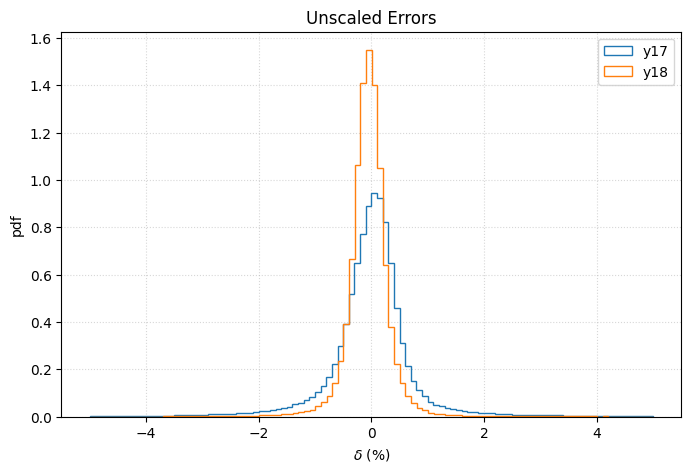

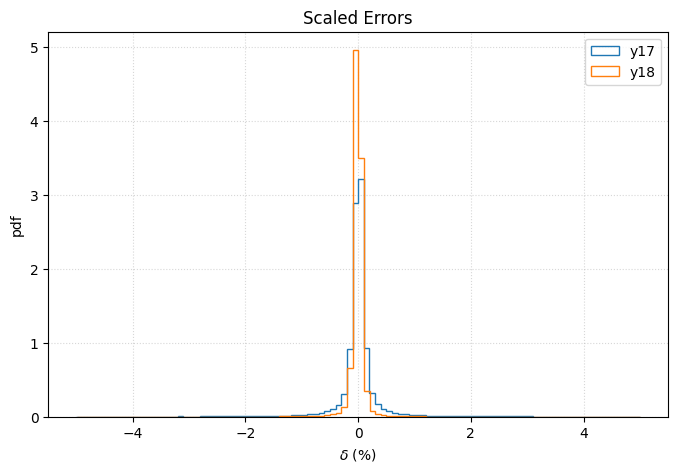

In [73]:
scaled_metrics, unscaled_metrics = evaluate_model(
    model, test_loader, get_device(), config, eps=1e-4
)


=== Evaluation (SCALED) ===
Overall MAPE: 0.003645
Overall R2  : 0.999974
Overall Abs : 99.635507
y17: MAPE=0.006011, R2=0.999968, abs=99.398862
y18: MAPE=0.001278, R2=0.999980, abs=99.872152

=== Evaluation (UNSCALED) ===
Overall MAPE: 0.007357
Overall R2  : 0.999798
Overall Abs : 99.264294
y17: MAPE=0.010468, R2=0.999645, abs=98.953178
y18: MAPE=0.004246, R2=0.999951, abs=99.575411


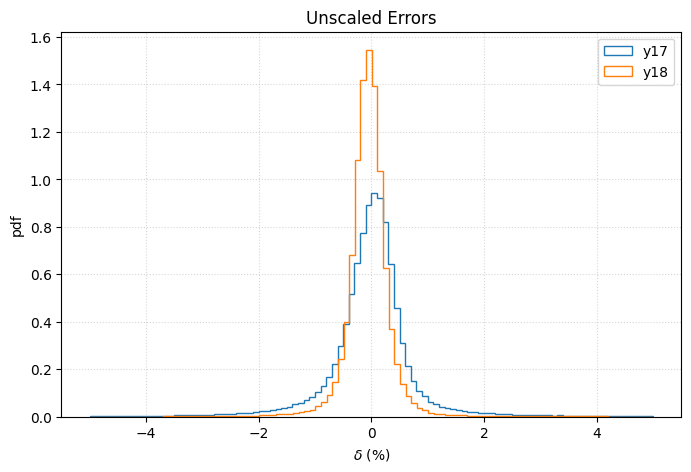

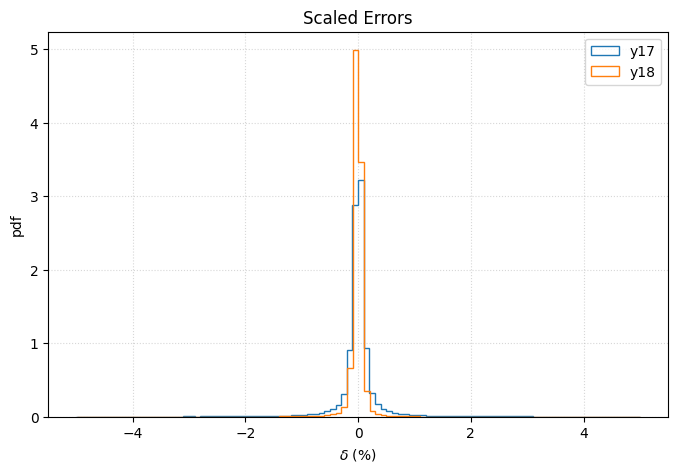

In [75]:
scaled_metrics, unscaled_metrics = evaluate_model(
    model, test_loader, get_device(), config, eps=1e-2
)


=== Evaluation (SCALED) ===
Overall MAPE: 0.007038
Overall R2  : 0.999974
Overall Abs : 99.296195
y17: MAPE=0.011984, R2=0.999968, abs=98.801570
y18: MAPE=0.002092, R2=0.999980, abs=99.790821

=== Evaluation (UNSCALED) ===
Overall MAPE: 0.010824
Overall R2  : 0.999798
Overall Abs : 98.917579
y17: MAPE=0.016581, R2=0.999645, abs=98.341899
y18: MAPE=0.005067, R2=0.999951, abs=99.493259


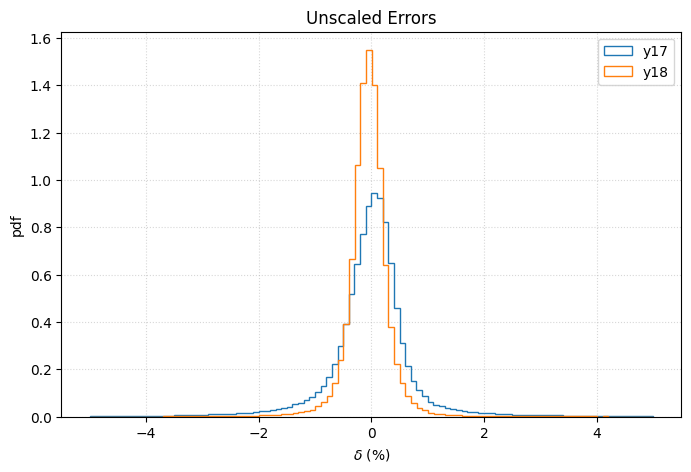

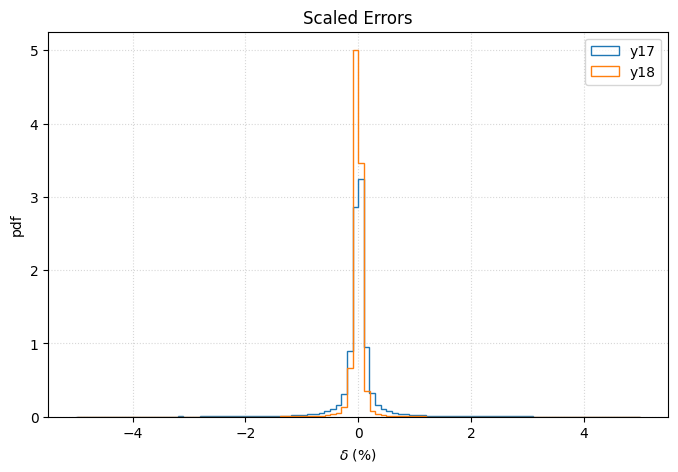

In [74]:
scaled_metrics, unscaled_metrics = evaluate_model(
    model, test_loader, get_device(), config, eps=1e-12
)


=== Evaluation (SCALED) ===
Overall MAPE: 0.002438
Overall R2  : 0.999974
Overall Abs : 99.756197
y17: MAPE=0.003822, R2=0.999968, abs=99.617840
y18: MAPE=0.001054, R2=0.999980, abs=99.894554

=== Evaluation (UNSCALED) ===
Overall MAPE: 0.006109
Overall R2  : 0.999798
Overall Abs : 99.389075
y17: MAPE=0.008199, R2=0.999645, abs=99.180140
y18: MAPE=0.004020, R2=0.999951, abs=99.598010


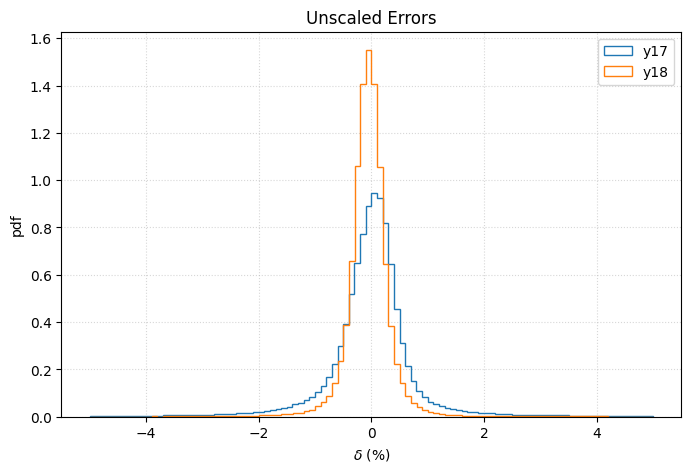

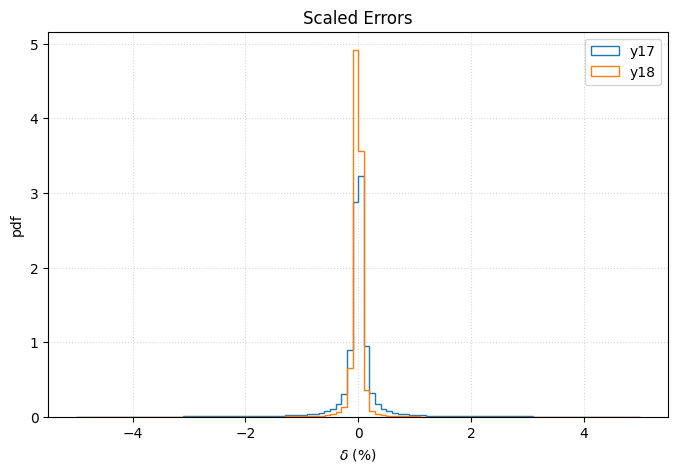

In [77]:
scaled_metrics, unscaled_metrics = evaluate_model(
    model, test_loader, get_device(), config, eps=1e-1
)


=== Evaluation (SCALED) ===
Overall MAPE: 0.000044
Overall R2  : 0.999974
Overall Abs : 99.995650
y17: MAPE=0.000055, R2=0.999968, abs=99.994468
y18: MAPE=0.000032, R2=0.999980, abs=99.996831

=== Evaluation (UNSCALED) ===
Overall MAPE: 0.001610
Overall R2  : 0.999798
Overall Abs : 99.839034
y17: MAPE=0.001716, R2=0.999645, abs=99.828386
y18: MAPE=0.001503, R2=0.999951, abs=99.849683


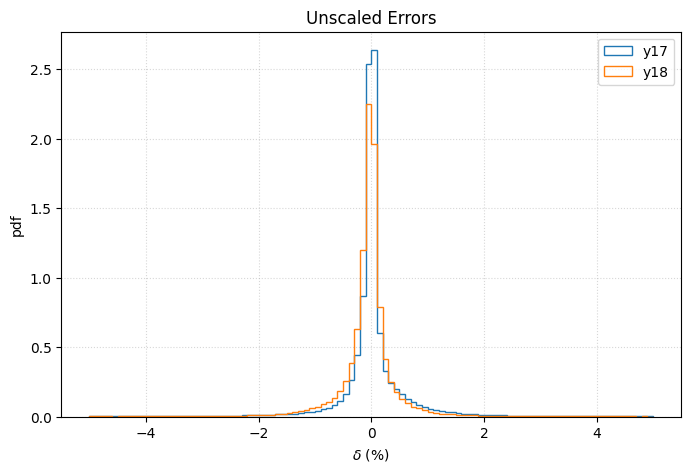

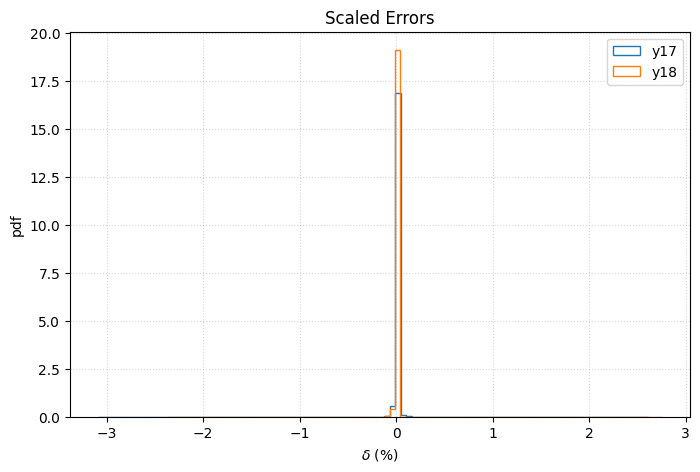

In [78]:
scaled_metrics, unscaled_metrics = evaluate_model(
    model, test_loader, get_device(), config, eps=100
)

In [56]:
# df_h2 = pd.read_csv('../models/skip-light-torch-4D-y5_y6-fe15fc3c--13-29-leaky_relu-1024-adam-exp-schedule-mse-val_mse-96.667286-99.840031/test-results-fe15fc3c-96.667286-99.840031.csv')
df_h2 = df_pred

In [57]:
df_h2

,x1,x2,x3,x4,y17_scaled,y18_scaled,y17,y18,y17_scaled_pred,y18_scaled_pred,y17_pred,y18_pred,scaled_delta_y17,scaled_delta_y18,delta_y17,delta_y18
0,0.00165641962550498322,0.77106551379827004133,0.43633664918354597706,0.52126188517413796220,-5.31189941655995223613,5.35002598532856943336,-201.73494101195908001500,209.61377066359986542921,-5.31378848550422588914,5.35134739705113915420,-202.11828325891178792517,209.89226212950970307247,0.03556296526218932080,0.02469916456842343941,0.19002273231883162752,0.13285933697398949471
1,0.00212429385715489066,0.58154222096262497832,0.51198411703238200232,0.52188992137343703792,-4.27504087946539357290,4.31627296199620769102,-70.88307779138780517769,73.90891898431800655089,-4.27357742107742666349,4.31281016278887285864,-70.77795683707384455374,73.64997303669909456403,-0.03423261740013862353,-0.08022660378117844882,-0.14830190447335891979,-0.35035818569319776561
2,0.00274296903628594001,0.46391536793583598719,0.52805102859570995921,0.50838622929786403404,3.48520214088431146138,-3.52809496697488533812,31.62902210266017988261,-33.05902221071146840359,3.49114266002807394074,-3.53754978202297065693,31.82343231015905615777,-33.38257110364206425857,0.17044977317313286802,0.26798641013317775483,0.61465766114383058039,0.97870073370095822529
3,0.00305240129214569885,0.96104947707754595498,0.54334391755274702440,0.50563056424363295172,-5.07557307142614533291,5.10770606540301042031,-159.06389374490885302293,164.29075347184323163674,-5.08591947350303819064,5.11016805064901724620,-160.72857603367737056033,164.69819822387012209219,0.20384697316525290933,0.04820138853884046309,1.04654943971016600734,0.24800224201097226251
4,0.00357230511091824986,0.36110424094076298829,0.52003743630701104728,0.52483906350981301969,4.77128084409596198157,-4.81672196075398417747,117.07037489373691130368,-122.55939365594497303391,4.77950897947941388821,-4.82197024707789889675,118.04588172059899875421,-123.20957340419491288230,0.17245129038324155668,0.10895971091287943999,0.83326531391698444029,0.53050176641307300596
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499707,0.50200678496299433462,0.16734086345217699665,0.52473690641435399851,0.52073850483759998031,-3.18125986870000243556,-3.66361027445788778323,-23.07706839655345376627,-38.00189655091408980070,-3.17945553229390132088,-3.66039658978706095027,-23.03366443494302018280,-37.87675793955397551827,-0.05671766786026326973,-0.08771906480424883357,-0.18808264925416581792,-0.32929570026184451503
499708,0.50222758834093395031,0.42052050509493399399,0.51396312248040398885,0.51941477260780299918,-1.69827640744173424814,-1.67288095498004740769,-4.46452066299195049481,-4.32749397987199557747,-1.69634670538494258807,-1.67021265194099211016,-4.45398593394240904786,-4.31329756009299369879,-0.11362708969728566033,-0.15950346204324639121,-0.23596551219636366370,-0.32805175108347117696
499709,0.50240343240609885989,0.55502246348075201521,0.52799983575339004549,0.67792711549142803396,1.44217161481511113585,1.45735029854727105025,3.22987150198357308994,3.29456512367945286712,1.44367055252621145911,1.45885351022848519520,3.23621657013395402913,3.30102561866833443815,0.10393615404034212135,0.10314690179242354262,0.19644955368918604055,0.19609553146930444600
499710,0.50251269256740993541,0.23320042534264701084,0.52506776667514498680,0.50383156056135103285,-2.90124851018143647963,-3.13311921860418163277,-17.19685014559850699811,-21.94543987724457068111,-2.90127100785791558479,-3.13332959621310758180,-17.19725953705118470793,-21.95026759182541908899,0.00077544810105557697,0.00671463784961471005,0.00238061882967848361,0.02199871411943904453


In [58]:
df_h2.describe()

,x1,x2,x3,x4,y17_scaled,y18_scaled,y17,y18,y17_scaled_pred,y18_scaled_pred,y17_pred,y18_pred,scaled_delta_y17,scaled_delta_y18,delta_y17,delta_y18
count,499712.00000000000000000000,499712.00000000000000000000,499712.00000000000000000000,499712.00000000000000000000,499712.00000000000000000000,499712.00000000000000000000,499712.00000000000000000000,499712.00000000000000000000,499712.00000000000000000000,499712.00000000000000000000,499712.00000000000000000000,499712.00000000000000000000,499712.00000000000000000000,499712.00000000000000000000,499712.00000000000000000000,499712.00000000000000000000
mean,0.28657586401584533853,0.50032965085829328444,0.51533538877065721007,0.51538469323664837241,-0.00555031004218283983,0.00753294400191350730,-0.18046243763975883256,0.30068379113219217968,-0.00541340108772284979,0.00715117555410534587,-0.26137079953462477588,0.24013103172712629840,0.15507578626141449440,-0.06939431015976590955,0.22518712865767406828,-0.01948308266804877134
std,0.12225085211389302708,0.33140055939995199941,0.07877847803778463553,0.07924851287791782883,4.02726363611660875819,4.77869035214326043359,157.11694036403500263077,183.03636679714222168514,4.02745253859285057274,4.77867003931686085139,156.96505504742799530504,182.96281451275862650618,87.77027214058637127891,28.21373645177588684874,89.92556117887978928138,29.36948272126857872877
min,0.00010773765831883648,0.00000026919476300000,0.00006108201031500000,0.00001116364142300000,-7.51210316506841557782,-6.61650876231441831266,-1829.05841312854272473487,-746.33142565565083259571,-7.45328836657990301262,-6.59890900842583860708,-1724.52799481129727610096,-733.29364390341277157859,-16566.66631708551722113043,-17903.51493401711195474491,-16639.21974198260068078525,-18021.97453120684076566249
25%,0.19820888331985311859,0.17937615969735648536,0.50068424613015927171,0.50049216661595097300,-3.91393702224305650716,-5.02260517255183458474,-49.09579248588838140677,-150.80627062655059944518,-3.91450400838815903981,-5.02301407681328804244,-49.12420416475036688553,-150.86835754576458157317,-0.07405638923170680676,-0.04915679272714856829,-0.31026934369807784853,-0.22951233482820287968
50%,0.28560071598160469142,0.50120935481691797353,0.51544926270982793781,0.51541143497406349816,-0.01139961857172889712,0.26617610704498406715,-0.01146484460616870038,0.30496558643292637214,-0.01461775242622229826,0.26609118978877066564,-0.01472511428783451759,0.30485526157364828403,0.00467576973012750856,-0.01070643905683992328,0.01878604240095091762,-0.05156761458224479178
75%,0.37206254635606728076,0.82105618327918472588,0.53088486642524479464,0.53093583185783854717,3.89577709783579706482,5.02643730021509860251,48.19426727176629299265,151.38912770893287529361,3.89781246808425807515,5.02460724301684535931,48.29449779974328293974,151.11050191792054420148,0.07736925536332862896,0.02590523029811168249,0.30632930735724278604,0.12540759569211346047
max,0.79568501288785942194,0.99999962850966694905,0.99974908042990195955,0.99999762313431894700,7.67612327080022360803,6.59544838189219273517,2155.24437223916311268113,730.75691969502190659114,7.65616764549642603299,6.61226553204017442056,2112.64166311969711387064,743.16704467189902061364,35596.05187380159622989595,905.32385499192253064393,36274.60880252817150903866,2555.01935246413086133543


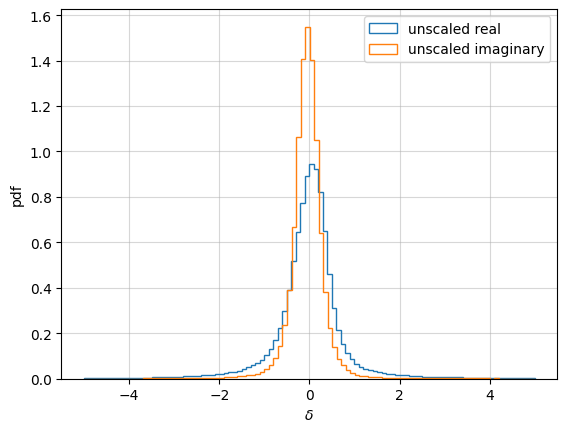

In [59]:
plt.hist(df_h2[abs(df_h2.delta_y17) < 5].delta_y17, bins=100, histtype='step', label='unscaled real', density=True)
plt.hist(df_h2[abs(df_h2.delta_y18) < 5].delta_y18, bins=100, histtype='step', label='unscaled imaginary', density=True)
plt.grid('dotted', alpha=0.5)
plt.xlabel(r'$\delta$')
plt.ylabel(r'pdf')
plt.legend()
plt.show()

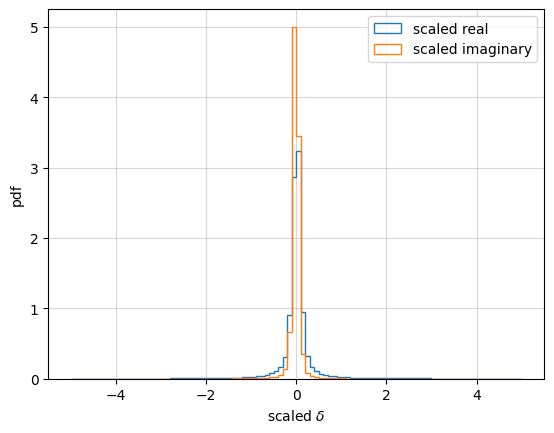

In [60]:
plt.hist(df_h2[abs(df_h2.scaled_delta_y17) < 5].scaled_delta_y17, bins=100, histtype='step', label='scaled real', density=True)
plt.hist(df_h2[abs(df_h2.scaled_delta_y18) < 5].scaled_delta_y18, bins=100, histtype='step', label='scaled imaginary', density=True)
plt.grid('dotted', alpha=0.5)
plt.xlabel(r'scaled $\delta$')
plt.ylabel(r'pdf')
plt.legend()
plt.show()

### Ensembling

In [2]:
from sklearn.metrics import r2_score

def ensemble_from_checkpoints(model, checkpoint_paths, dataloader, device, config, eps=1e-6):
    """
    Evaluate ensemble of multiple checkpoints using a pre-created model.
    It loads each checkpoint, collects predictions, averages them, and runs full evaluation.
    """
    assert len(checkpoint_paths) > 0, "No checkpoints provided for ensemble"

    all_preds, all_targets = [], []
    model.eval()

    with torch.no_grad():
        for xb, yb in dataloader:
            xb = xb.to(device)

            preds_per_ckpt = []
            for path in checkpoint_paths:
                # load weights into same model each time
                state = torch.load(path, map_location=device)
                model.load_state_dict(state)
                preds_per_ckpt.append(model(xb).cpu())

            # average predictions from all checkpoints
            mean_pred = torch.stack(preds_per_ckpt, dim=0).mean(dim=0)
            all_preds.append(mean_pred)
            all_targets.append(yb.cpu())

    y_true = torch.cat(all_targets, dim=0).numpy()
    y_pred = torch.cat(all_preds, dim=0).numpy()
    y_names = config["var_y"]

    # ---------- metrics ----------
    scaled = {}
    overall_mape = safe_mape(y_true, y_pred, eps=eps)
    overall_r2   = r2_score(y_true, y_pred)
    overall_abs  = (1 - overall_mape) * 100 if np.isfinite(overall_mape) else np.nan
    scaled["overall"] = {"MAPE": overall_mape, "R2": overall_r2, "abs_score": overall_abs}
    scaled["per_target"] = {}
    for j, name in enumerate(y_names):
        mape_j = safe_mape(y_true[:, j], y_pred[:, j], eps=eps)
        r2_j   = r2_score(y_true[:, j], y_pred[:, j])
        abs_j  = (1 - mape_j) * 100 if np.isfinite(mape_j) else np.nan
        scaled["per_target"][name] = {"MAPE": mape_j, "R2": r2_j, "abs_score": abs_j}

    # ---------- unscaled ----------
    y_unscale_vec = np.vectorize(y_unscale)
    y_true_un = y_unscale_vec(y_true)
    y_pred_un = y_unscale_vec(y_pred)

    unscaled = {}
    overall_mape_un = safe_mape(y_true_un, y_pred_un, eps=eps)
    overall_r2_un   = r2_score(y_true_un, y_pred_un)
    overall_abs_un  = (1 - overall_mape_un) * 100 if np.isfinite(overall_mape_un) else np.nan
    unscaled["overall"] = {"MAPE": overall_mape_un, "R2": overall_r2_un, "abs_score": overall_abs_un}
    unscaled["per_target"] = {}
    for j, name in enumerate(y_names):
        mape_j_un = safe_mape(y_true_un[:, j], y_pred_un[:, j], eps=eps)
        r2_j_un   = r2_score(y_true_un[:, j], y_pred_un[:, j])
        abs_j_un  = (1 - mape_j_un) * 100 if np.isfinite(mape_j_un) else np.nan
        unscaled["per_target"][name] = {"MAPE": mape_j_un, "R2": r2_j_un, "abs_score": abs_j_un}

    # ---------- print + plots ----------
    print("\n=== Ensemble Evaluation (SCALED) ===")
    print(f"Overall MAPE: {scaled['overall']['MAPE']:.6f}")
    print(f"Overall R2  : {scaled['overall']['R2']:.6f}")
    print(f"Overall Abs : {scaled['overall']['abs_score']:.6f}")
    for n, v in scaled["per_target"].items():
        print(f"{n}: MAPE={v['MAPE']:.6f}, R2={v['R2']:.6f}, abs={v['abs_score']:.6f}")

    print("\n=== Ensemble Evaluation (UNSCALED) ===")
    print(f"Overall MAPE: {unscaled['overall']['MAPE']:.6f}")
    print(f"Overall R2  : {unscaled['overall']['R2']:.6f}")
    print(f"Overall Abs : {unscaled['overall']['abs_score']:.6f}")
    for n, v in unscaled["per_target"].items():
        print(f"{n}: MAPE={v['MAPE']:.6f}, R2={v['R2']:.6f}, abs={v['abs_score']:.6f}")

    scaled_delta   = _percent_delta(y_true, y_pred, eps=eps)
    unscaled_delta = _percent_delta(y_true_un, y_pred_un, eps=eps)
    _plot_error_histograms(unscaled_delta, y_names, cutoff=5, title="Unscaled Ensemble Errors")
    _plot_error_histograms(scaled_delta, y_names, cutoff=5, title="Scaled Ensemble Errors")

    return scaled, unscaled


In [8]:
width = config['width']
depth = config['depth']
n_skip_layers = config['skip_block_layers']
activation = config['activation']

model = SkipModel(config["input_shape"], width, depth, n_skip_layers, len(y_cols), activation)
model.to(device=get_device())

NameError: name 'config' is not defined

In [21]:
config = {
    "model_type": "skip-mini",
    "input_shape": 4,
    "amplitude_shape": 36,
    "data_dir": "/scratch/akula.ha/dataset",
    "seed": 42,
    "var_y": [
        "y5",
        "y6"
    ],
    "use_MC_sample": True,
    "val_MC": False,
    "train-sample-size": 10000000,
    "validate-sample-size": 500000,
    "test-sample-size": 500000,
    "activation": "leaky_relu",
    "width": 30,
    "depth": 12,
    "skip_block_layers": 5,
    "lr_decay_type": "plateau",
    "initial_lr": 0.001,
    "lr_patience": 20,
    "lr_factor": 0.8,
    "lr_delta": 1e-05,
    "batch_size": 1024,
    "steps_per_epoch": 2400,
    "early_stopping_start_epoch": 200,
    "patience": 150,
    "loss": "huber",
    "base_directory": "../models/",
    "epochs": 2000,
    "model-uuid": "UUID",
    "train-samples-used": 6,
    "validate-samples-used": 6,
    "test-samples-used": 6,
    "n_targets": 2,
    "load_checkpoint_path": "/projects/talisman/akulaha/qqzz4l-NN/models/skip-mini_1ecf92bf_30_12_5"
}

/tmp/ipykernel_313737/3089122792.py:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(path, map_location=device)



=== Ensemble Evaluation (SCALED) ===
Overall MAPE: 0.002711
Overall R2  : 0.999993
Overall Abs : 99.728907
y5: MAPE=0.003113, R2=0.999994, abs=99.688702
y6: MAPE=0.002309, R2=0.999993, abs=99.769112

=== Ensemble Evaluation (UNSCALED) ===
Overall MAPE: 0.004181
Overall R2  : 0.999954
Overall Abs : 99.581895
y5: MAPE=0.004728, R2=0.999924, abs=99.527249
y6: MAPE=0.003635, R2=0.999983, abs=99.636541


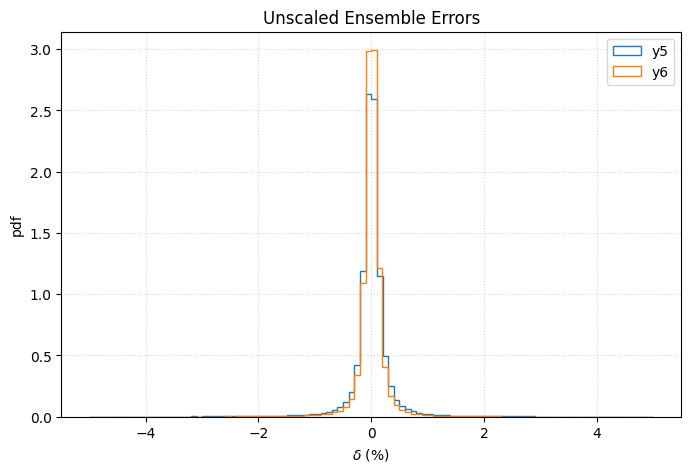

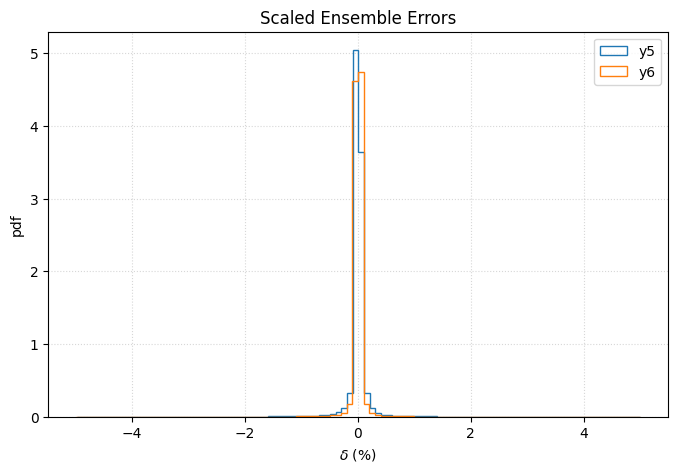

In [22]:
checkpoint_paths = [
    "/projects/talisman/akulaha/qqzz4l-NN/models/skip-mini_6274a706_30_12_5/6274a706.best_weights.pt",
    "/projects/talisman/akulaha/qqzz4l-NN/models/skip-mini_smallhuberv1_30_12_5/smallhuberv1.best_weights.pt",
    "/projects/talisman/akulaha/qqzz4l-NN/models/skip-mini_y5y6exp_30_12_5/y5y6exp.best_weights.pt",
    # "/projects/talisman/akulaha/qqzz4l-NN/models/skip-mini_b022ce8d_30_12_5/b022ce8d.best_weights.pt",
    "/projects/talisman/akulaha/qqzz4l-NN/models/skip-mini_y5y6expv2_30_12_5/y5y6expv2.best_weights.pt"

]

scaled_metrics, unscaled_metrics = ensemble_from_checkpoints(
    model=model,
    checkpoint_paths=checkpoint_paths,
    dataloader=test_loader,
    device=get_device(),
    config=config,
    eps=0
)


/tmp/ipykernel_2012389/3089122792.py:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(path, map_location=device)



=== Ensemble Evaluation (SCALED) ===
Overall MAPE: 0.003605
Overall R2  : 0.999980
Overall Abs : 99.639526
y5: MAPE=0.004821, R2=0.999990, abs=99.517939
y6: MAPE=0.002389, R2=0.999970, abs=99.761113

=== Ensemble Evaluation (UNSCALED) ===
Overall MAPE: 0.006664
Overall R2  : 0.999842
Overall Abs : 99.333627
y5: MAPE=0.008434, R2=0.999739, abs=99.156556
y6: MAPE=0.004893, R2=0.999945, abs=99.510699


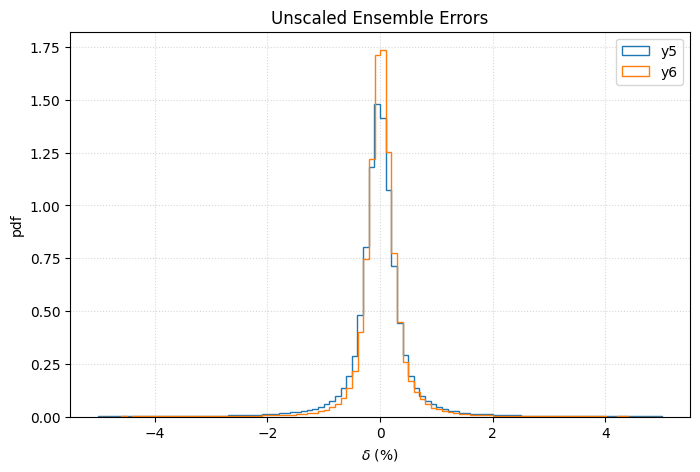

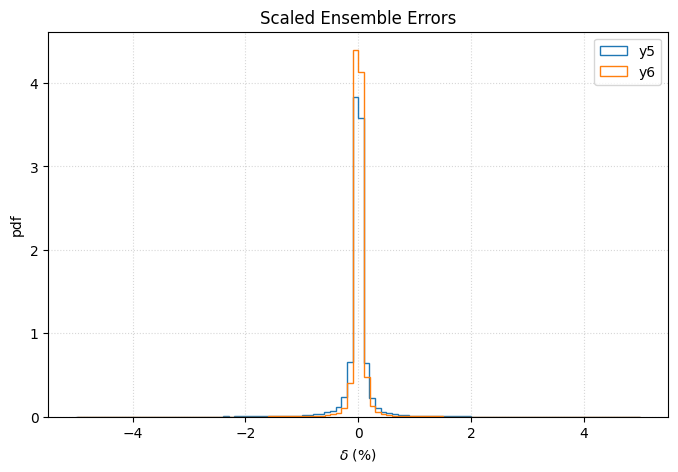

Combo size=1 → abs_score=99.333627 for ('/projects/talisman/akulaha/qqzz4l-NN/models/skip-mini_6274a706_30_12_5/6274a706.best_weights.pt',)


/tmp/ipykernel_2012389/3089122792.py:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(path, map_location=device)



=== Ensemble Evaluation (SCALED) ===
Overall MAPE: 0.004372
Overall R2  : 0.999984
Overall Abs : 99.562836
y5: MAPE=0.006510, R2=0.999987, abs=99.349007
y6: MAPE=0.002233, R2=0.999982, abs=99.776664

=== Ensemble Evaluation (UNSCALED) ===
Overall MAPE: 0.007829
Overall R2  : 0.999873
Overall Abs : 99.217144
y5: MAPE=0.010921, R2=0.999787, abs=98.907884
y6: MAPE=0.004736, R2=0.999958, abs=99.526403


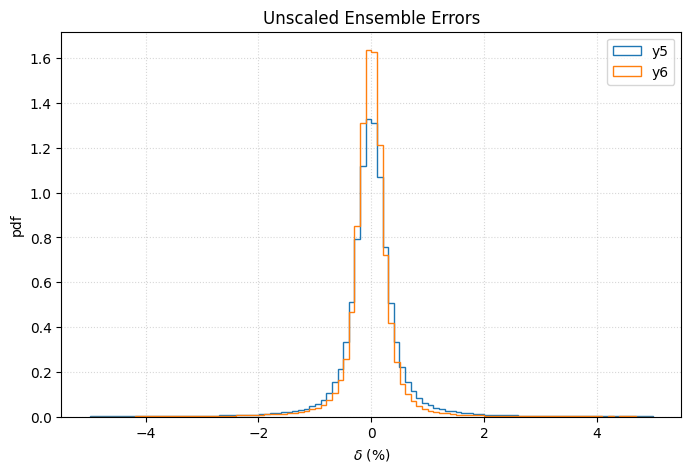

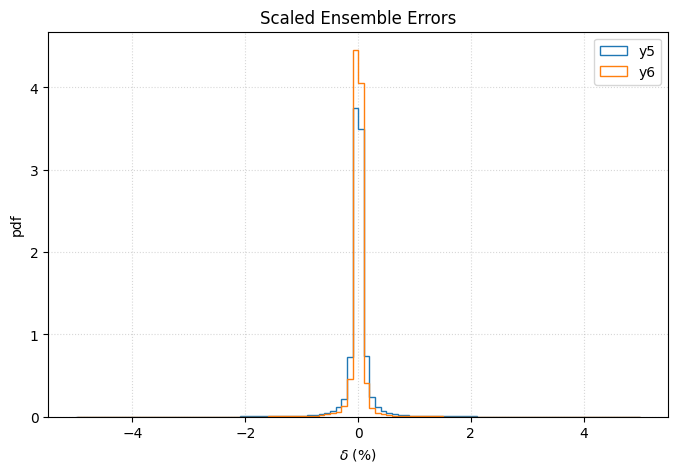

Combo size=1 → abs_score=99.217144 for ('/projects/talisman/akulaha/qqzz4l-NN/models/skip-mini_y5y6m1_30_12_5/y5y6m1.best_weights.pt',)


/tmp/ipykernel_2012389/3089122792.py:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(path, map_location=device)


KeyboardInterrupt: 

In [24]:
import itertools
import torch

best_score = -float("inf")
best_combo = None

# collect all non-commented checkpoints
checkpoint_paths = [
    "/projects/talisman/akulaha/qqzz4l-NN/models/skip-mini_6274a706_30_12_5/6274a706.best_weights.pt",
    "/projects/talisman/akulaha/qqzz4l-NN/models/skip-mini_y5y6m1_30_12_5/y5y6m1.best_weights.pt",
    "/projects/talisman/akulaha/qqzz4l-NN/models/skip-mini_y5y6m2_30_12_5/y5y6m2.best_weights.pt",
    "/projects/talisman/akulaha/qqzz4l-NN/models/skip-mini_y5y6m3_30_12_5/y5y6m3.best_weights.pt",
    # "/projects/talisman/akulaha/qqzz4l-NN/models/skip-mini_smallhuberv1_30_12_5/smallhuberv1.best_weights.pt",
    # "/projects/talisman/akulaha/qqzz4l-NN/models/skip-mini_4ddd0926_30_12_5/4ddd0926.best_weights.pt",
    # "/projects/talisman/akulaha/qqzz4l-NN/models/skip-mini_y5y6exp_30_12_5/y5y6exp.best_weights.pt",
    # "/projects/talisman/akulaha/qqzz4l-NN/models/skip-mini_b022ce8d_30_12_5/b022ce8d.best_weights.pt",
    # "/projects/talisman/akulaha/qqzz4l-NN/models/skip-mini_y5y6expv2_30_12_5/y5y6expv2.best_weights.pt"
]

# try combinations of 1 to all
for r in range(1, len(checkpoint_paths) + 1):
    for combo in itertools.combinations(checkpoint_paths, r):
        scaled_metrics, unscaled_metrics = ensemble_from_checkpoints(
            model=model,
            checkpoint_paths=combo,
            dataloader=test_loader,
            device=get_device(),
            config=config,
            eps=0
        )
        score = unscaled_metrics['overall']['abs_score']
        print(f"Combo size={r} → abs_score={score:.6f} for {combo}")

        if score > best_score:
            best_score = score
            best_combo = combo

print("\n=== Best Combination ===")
print(f"abs_score={best_score:.6f}")
for path in best_combo:
    print(" ", path)


/tmp/ipykernel_2012389/3089122792.py:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(path, map_location=device)



=== Ensemble Evaluation (SCALED) ===
Overall MAPE: 0.002213
Overall R2  : 0.999992
Overall Abs : 99.778694
y5: MAPE=0.002835, R2=0.999992, abs=99.716467
y6: MAPE=0.001591, R2=0.999992, abs=99.840922

=== Ensemble Evaluation (UNSCALED) ===
Overall MAPE: 0.003658
Overall R2  : 0.999949
Overall Abs : 99.634210
y5: MAPE=0.004436, R2=0.999916, abs=99.556447
y6: MAPE=0.002880, R2=0.999982, abs=99.711974


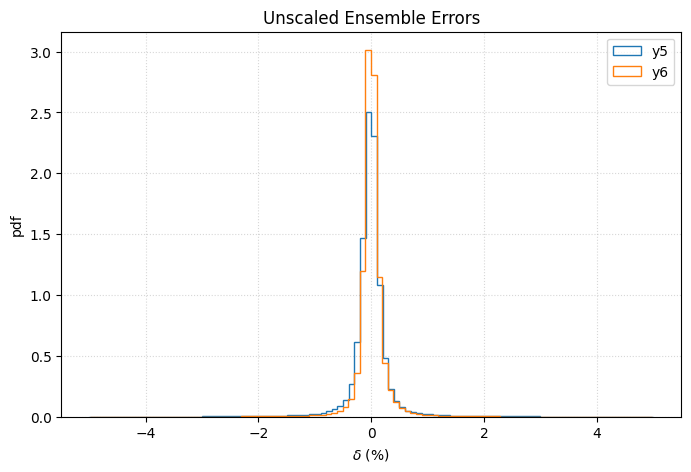

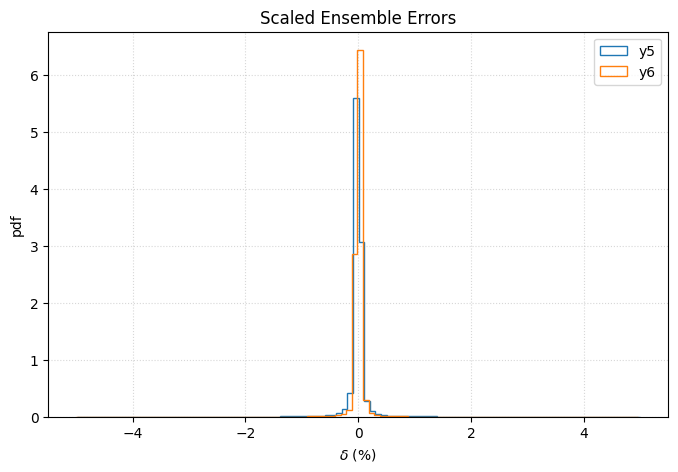

99.63421047640428


In [25]:
checkpoint_paths = [
    "/projects/talisman/akulaha/qqzz4l-NN/models/skip-mini_6274a706_30_12_5/6274a706.best_weights.pt",
    "/projects/talisman/akulaha/qqzz4l-NN/models/skip-mini_y5y6m1_30_12_5/y5y6m1.best_weights.pt",
    "/projects/talisman/akulaha/qqzz4l-NN/models/skip-mini_y5y6m2_30_12_5/y5y6m2.best_weights.pt",
    "/projects/talisman/akulaha/qqzz4l-NN/models/skip-mini_y5y6m3_30_12_5/y5y6m3.best_weights.pt",
    # "/projects/talisman/akulaha/qqzz4l-NN/models/skip-mini_smallhuberv1_30_12_5/smallhuberv1.best_weights.pt",
    # "/projects/talisman/akulaha/qqzz4l-NN/models/skip-mini_4ddd0926_30_12_5/4ddd0926.best_weights.pt",
    # "/projects/talisman/akulaha/qqzz4l-NN/models/skip-mini_y5y6exp_30_12_5/y5y6exp.best_weights.pt",
    # "/projects/talisman/akulaha/qqzz4l-NN/models/skip-mini_b022ce8d_30_12_5/b022ce8d.best_weights.pt",
    # "/projects/talisman/akulaha/qqzz4l-NN/models/skip-mini_y5y6expv2_30_12_5/y5y6expv2.best_weights.pt"
]
scaled_metrics, unscaled_metrics = ensemble_from_checkpoints(
    model=model,
    checkpoint_paths=checkpoint_paths,
    dataloader=test_loader,
    device=get_device(),
    config=config,
    eps=0
)

print(unscaled_metrics['overall']['abs_score'])

/tmp/ipykernel_1110662/3089122792.py:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(path, map_location=device)



=== Ensemble Evaluation (SCALED) ===
Overall MAPE: 0.004578
Overall R2  : 0.999976
Overall Abs : 99.542236
y5: MAPE=0.005932, R2=0.999975, abs=99.406828
y6: MAPE=0.003224, R2=0.999978, abs=99.677644

=== Ensemble Evaluation (UNSCALED) ===
Overall MAPE: 0.007997
Overall R2  : 0.999739
Overall Abs : 99.200268
y5: MAPE=0.009969, R2=0.999542, abs=99.003070
y6: MAPE=0.006025, R2=0.999937, abs=99.397466


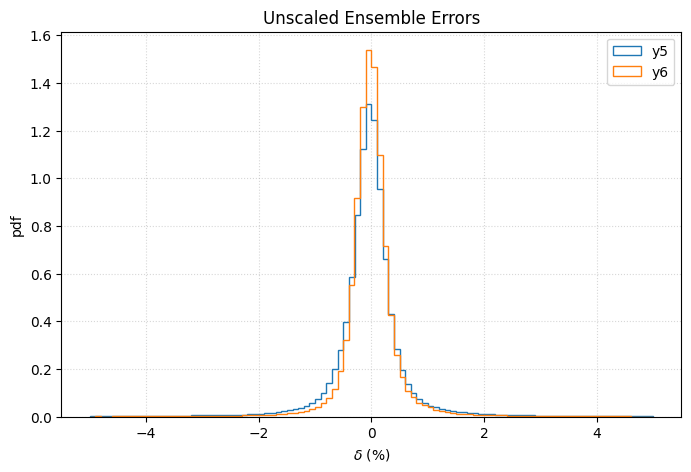

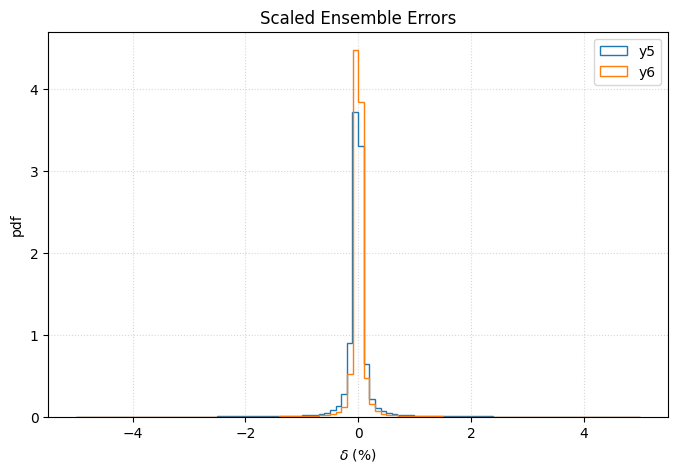

99.20026808601523


In [29]:
checkpoint_paths = [
    # "/projects/talisman/akulaha/qqzz4l-NN/models/skip-mini_6274a706_30_12_5/6274a706.best_weights.pt", # (abs 99.333627)
    # "/projects/talisman/akulaha/qqzz4l-NN/models/skip-mini_y5y6m1_30_12_5/y5y6m1.best_weights.pt", # abs 99.217144
    # "/projects/talisman/akulaha/qqzz4l-NN/models/skip-mini_y5y6m2_30_12_5/y5y6m2.best_weights.pt", # abs 99.262336
    # "/projects/talisman/akulaha/qqzz4l-NN/models/skip-mini_y5y6m3_30_12_5/y5y6m3.best_weights.pt", # 99.200268
    # "/projects/talisman/akulaha/qqzz4l-NN/models/skip-mini_smallhuberv1_30_12_5/smallhuberv1.best_weights.pt",
    # "/projects/talisman/akulaha/qqzz4l-NN/models/skip-mini_4ddd0926_30_12_5/4ddd0926.best_weights.pt",
    # "/projects/talisman/akulaha/qqzz4l-NN/models/skip-mini_y5y6exp_30_12_5/y5y6exp.best_weights.pt",
    # "/projects/talisman/akulaha/qqzz4l-NN/models/skip-mini_b022ce8d_30_12_5/b022ce8d.best_weights.pt",
    # "/projects/talisman/akulaha/qqzz4l-NN/models/skip-mini_y5y6expv2_30_12_5/y5y6expv2.best_weights.pt"
]
scaled_metrics, unscaled_metrics = ensemble_from_checkpoints(
    model=model,
    checkpoint_paths=checkpoint_paths,
    dataloader=test_loader,
    device=get_device(),
    config=config,
    eps=0
)

print(unscaled_metrics['overall']['abs_score'])

/tmp/ipykernel_1110662/3089122792.py:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(path, map_location=device)



=== Ensemble Evaluation (SCALED) ===
Overall MAPE: 0.002213
Overall R2  : 0.999992
Overall Abs : 99.778694
y5: MAPE=0.002835, R2=0.999992, abs=99.716467
y6: MAPE=0.001591, R2=0.999992, abs=99.840922

=== Ensemble Evaluation (UNSCALED) ===
Overall MAPE: 0.003658
Overall R2  : 0.999949
Overall Abs : 99.634210
y5: MAPE=0.004436, R2=0.999916, abs=99.556447
y6: MAPE=0.002880, R2=0.999982, abs=99.711974


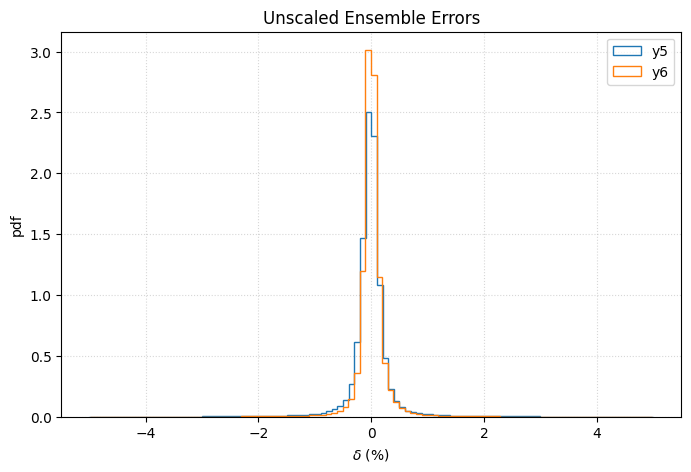

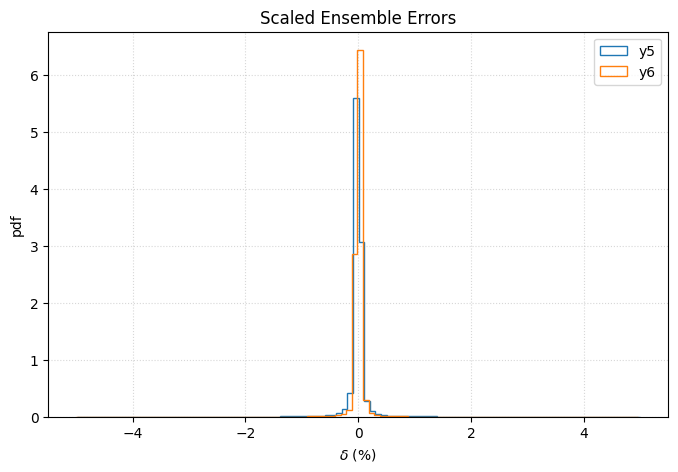

99.63421047640428


In [33]:
checkpoint_paths = [
    "/projects/talisman/akulaha/qqzz4l-NN/models/skip-mini_6274a706_30_12_5/6274a706.best_weights.pt", # abs 99.333627
    "/projects/talisman/akulaha/qqzz4l-NN/models/skip-mini_y5y6m2_30_12_5/y5y6m2.best_weights.pt",     # abs 99.262336
    "/projects/talisman/akulaha/qqzz4l-NN/models/skip-mini_y5y6m1_30_12_5/y5y6m1.best_weights.pt",     # abs 99.217144
    "/projects/talisman/akulaha/qqzz4l-NN/models/skip-mini_y5y6m3_30_12_5/y5y6m3.best_weights.pt",     # abs 99.200268
]
scaled_metrics, unscaled_metrics = ensemble_from_checkpoints(
    model=model,
    checkpoint_paths=checkpoint_paths,
    dataloader=test_loader,
    device=get_device(),
    config=config,
    eps=0
)

print(unscaled_metrics['overall']['abs_score'])

In [31]:
unscaled_metrics

{'overall': {'MAPE': 0.00799731913984774,
  'R2': 0.9997394464750375,
  'abs_score': 99.20026808601523},
 'per_target': {'y5': {'MAPE': 0.009969299996978757,
   'R2': 0.9995423555811985,
   'abs_score': 99.00307000030213},
  'y6': {'MAPE': 0.006025338282716725,
   'R2': 0.9999365373688766,
   'abs_score': 99.39746617172833}}}

/tmp/ipykernel_1110662/3089122792.py:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(path, map_location=device)



=== Ensemble Evaluation (SCALED) ===
Overall MAPE: 0.003605
Overall R2  : 0.999980
Overall Abs : 99.639526
y5: MAPE=0.004821, R2=0.999990, abs=99.517939
y6: MAPE=0.002389, R2=0.999970, abs=99.761113

=== Ensemble Evaluation (UNSCALED) ===
Overall MAPE: 0.006664
Overall R2  : 0.999842
Overall Abs : 99.333627
y5: MAPE=0.008434, R2=0.999739, abs=99.156556
y6: MAPE=0.004893, R2=0.999945, abs=99.510699


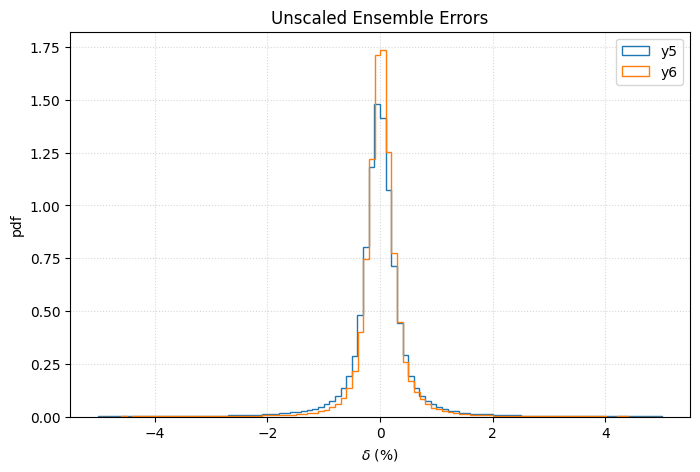

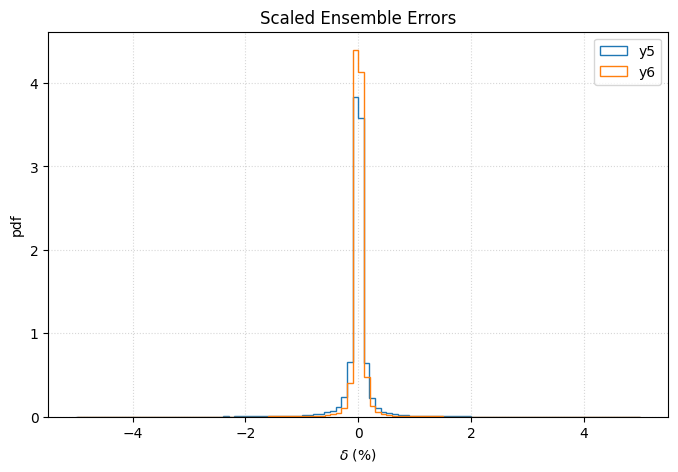

Ensemble size 1:
  unscaled abs_score = 99.33362714545967
  scaled   abs_score = 99.6395260857145
  unscaled R2        = 0.9998419923377897
  scaled   R2        = 0.9999803810859609


/tmp/ipykernel_1110662/3089122792.py:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(path, map_location=device)



=== Ensemble Evaluation (SCALED) ===
Overall MAPE: 0.003093
Overall R2  : 0.999987
Overall Abs : 99.690716
y5: MAPE=0.003847, R2=0.999991, abs=99.615319
y6: MAPE=0.002339, R2=0.999982, abs=99.766113

=== Ensemble Evaluation (UNSCALED) ===
Overall MAPE: 0.005093
Overall R2  : 0.999918
Overall Abs : 99.490731
y5: MAPE=0.006014, R2=0.999866, abs=99.398637
y6: MAPE=0.004172, R2=0.999970, abs=99.582825


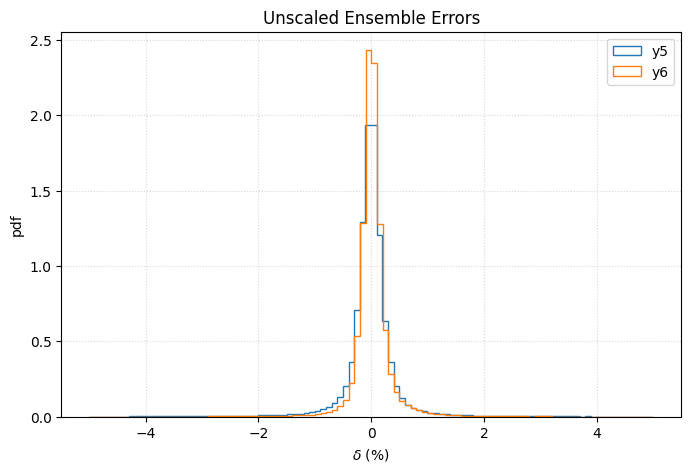

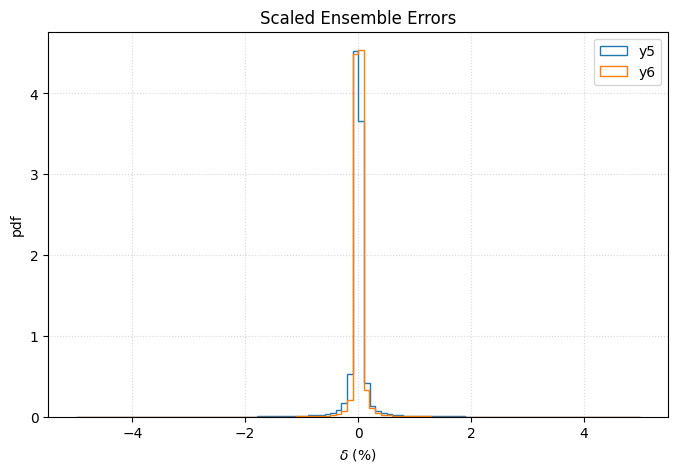

Ensemble size 2:
  unscaled abs_score = 99.49073129374362
  scaled   abs_score = 99.69071600638962
  unscaled R2        = 0.9999178279278993
  scaled   R2        = 0.999986543386254


/tmp/ipykernel_1110662/3089122792.py:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(path, map_location=device)



=== Ensemble Evaluation (SCALED) ===
Overall MAPE: 0.002655
Overall R2  : 0.999991
Overall Abs : 99.734488
y5: MAPE=0.003384, R2=0.999993, abs=99.661624
y6: MAPE=0.001926, R2=0.999988, abs=99.807353

=== Ensemble Evaluation (UNSCALED) ===
Overall MAPE: 0.004282
Overall R2  : 0.999948
Overall Abs : 99.571767
y5: MAPE=0.005178, R2=0.999916, abs=99.482242
y6: MAPE=0.003387, R2=0.999980, abs=99.661293


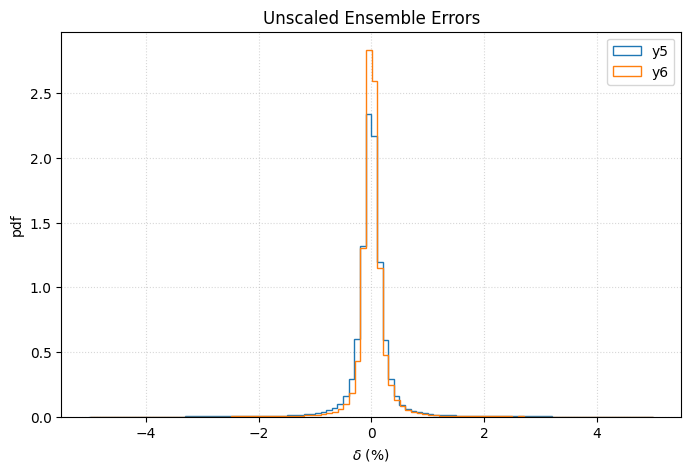

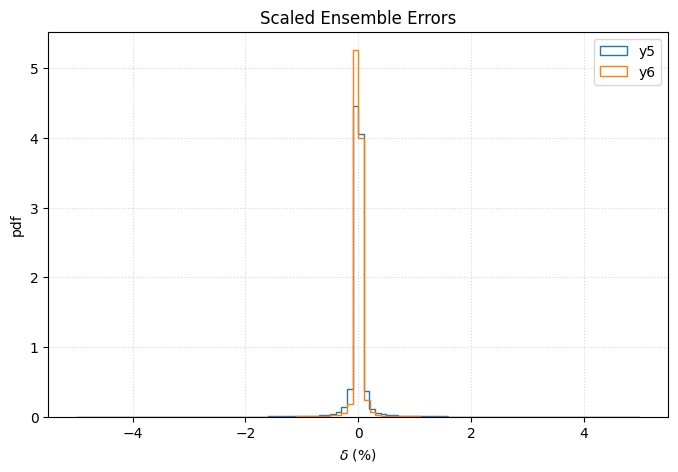

Ensemble size 3:
  unscaled abs_score = 99.57176735849058
  scaled   abs_score = 99.73448836882979
  unscaled R2        = 0.9999478623483858
  scaled   R2        = 0.9999906623383803


/tmp/ipykernel_1110662/3089122792.py:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(path, map_location=device)



=== Ensemble Evaluation (SCALED) ===
Overall MAPE: 0.002213
Overall R2  : 0.999992
Overall Abs : 99.778694
y5: MAPE=0.002835, R2=0.999992, abs=99.716467
y6: MAPE=0.001591, R2=0.999992, abs=99.840922

=== Ensemble Evaluation (UNSCALED) ===
Overall MAPE: 0.003658
Overall R2  : 0.999949
Overall Abs : 99.634210
y5: MAPE=0.004436, R2=0.999916, abs=99.556447
y6: MAPE=0.002880, R2=0.999982, abs=99.711974


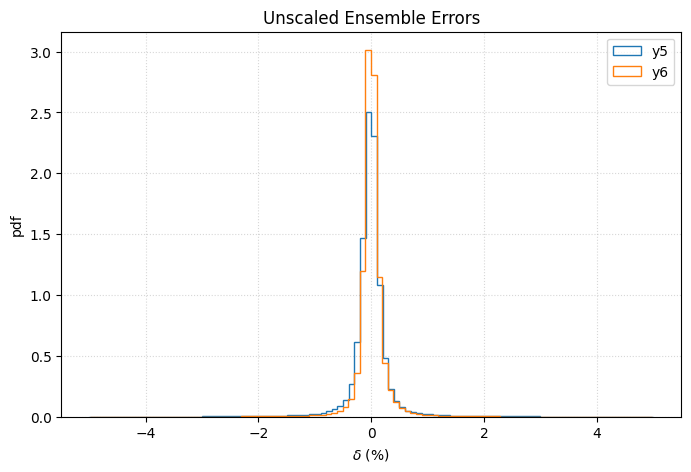

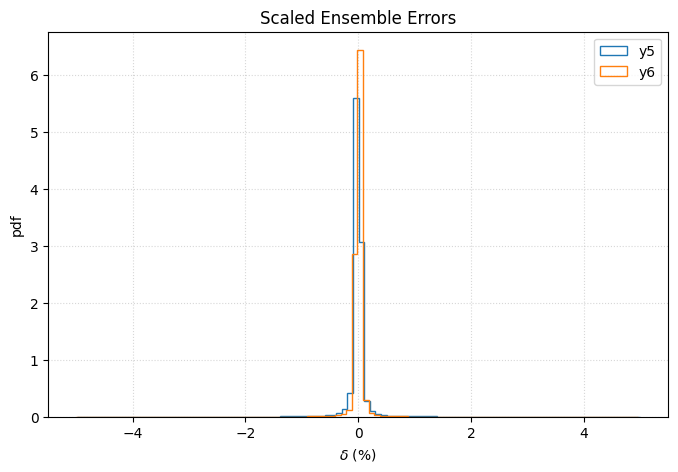

Ensemble size 4:
  unscaled abs_score = 99.63421047640428
  scaled   abs_score = 99.77869437570662
  unscaled R2        = 0.9999492350740347
  scaled   R2        = 0.999991870595638


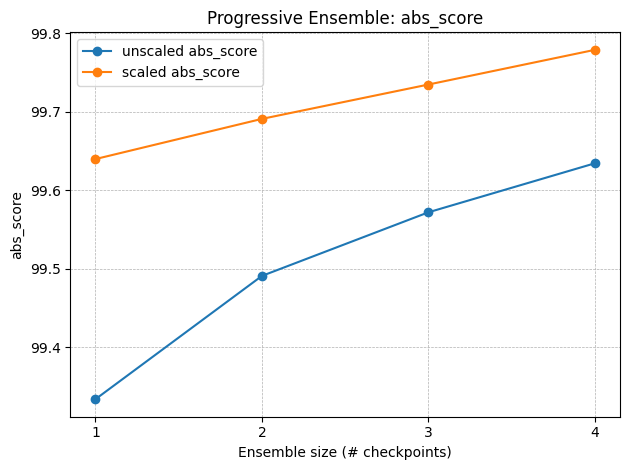

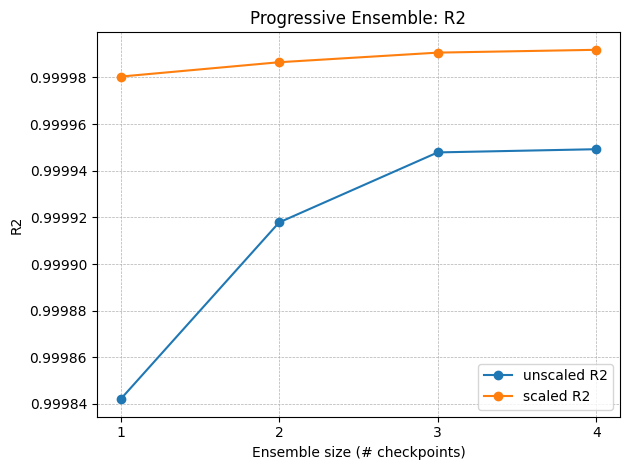

In [35]:
import matplotlib.pyplot as plt

def progressive_ensembles(checkpoint_paths):
    """
    Returns:
      [
        [path0],
        [path0, path1],
        [path0, path1, path2],
        ...
      ]
    """
    return [checkpoint_paths[:k] for k in range(1, len(checkpoint_paths) + 1)]

ensemble_path_lists = progressive_ensembles(checkpoint_paths)

abs_unscaled = []
abs_scaled = []
r2_unscaled = []
r2_scaled = []

for k, paths_k in enumerate(ensemble_path_lists, start=1):
    scaled_metrics, unscaled_metrics = ensemble_from_checkpoints(
        model=model,
        checkpoint_paths=paths_k,
        dataloader=test_loader,
        device=get_device(),
        config=config,
        eps=0
    )

    # Collect metrics
    abs_unscaled.append(unscaled_metrics["overall"]["abs_score"])
    abs_scaled.append(scaled_metrics["overall"]["abs_score"])

    r2_unscaled.append(unscaled_metrics["overall"]["R2"])
    r2_scaled.append(scaled_metrics["overall"]["R2"])

    print(f"Ensemble size {k}:")
    print(f"  unscaled abs_score = {abs_unscaled[-1]}")
    print(f"  scaled   abs_score = {abs_scaled[-1]}")
    print(f"  unscaled R2        = {r2_unscaled[-1]}")
    print(f"  scaled   R2        = {r2_scaled[-1]}")

x = list(range(1, len(ensemble_path_lists) + 1))

# Plot abs_score (unscaled + scaled)
plt.figure()
plt.plot(x, abs_unscaled, marker="o", label="unscaled abs_score")
plt.plot(x, abs_scaled, marker="o", label="scaled abs_score")
plt.xticks(x)
plt.xlabel("Ensemble size (# checkpoints)")
plt.ylabel("abs_score")
plt.title("Progressive Ensemble: abs_score")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# Plot R2 (unscaled + scaled)
plt.figure()
plt.plot(x, r2_unscaled, marker="o", label="unscaled R2")
plt.plot(x, r2_scaled, marker="o", label="scaled R2")
plt.xticks(x)
plt.xlabel("Ensemble size (# checkpoints)")
plt.ylabel("R2")
plt.title("Progressive Ensemble: R2")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()
